## Astro kod

### Parser

In [ ]:
# Parser
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits


from os import listdir
from os.path import isfile, join
import time
from datetime import datetime


# Returnerar lista av (band (int), tidpunkt (datetime), bild_data (np.ndarray av ra, dec, intensitet))
def parseFits(fits_dir):
    # Hämta lista av fits filer från mapp
    fits_files = [fits_file for fits_file in listdir(fits_dir) if isfile(join(fits_dir, fits_file))]

    observations = list()
    date_format = "%Y-%m-%dT%H:%M:%S.%f"

    # Gå igenom varje fits fil
    for fits_file in fits_files:
        # Öppna fitsfil
        # HDUList (Header Data Unit)
        hdul = fits.open(fits_dir + fits_file)
        # hdul.info() # Printar lite info om fitsfilen

        # Header information
        # Se: http://www.alma.inaf.it/images/ArchiveKeyworkds.pdf
        header = hdul[0].header
        #print(repr(header))

        # Få band
        band = int(fits_file[fits_file.find('B')+1])

        # Få observationsdatum och tid
        date_str = header['DATE-OBS']
        date = datetime.strptime(date_str, date_format)

        # Bilddatan
        intensities = np.squeeze(hdul[0].data)

        width, height = intensities.shape
        x_pixels = np.linspace(0, width, width)
        y_pixels = np.linspace(0, height, height)

        # Right ascension
        ra_ref = header['CRVAL1'] # RA referens i relation till Pixel referensen
        ra_delta = header['CDELT1'] # RA delta för varje pixel
        ra_pixel_ref = header['CRPIX1'] # Pixel positionen där RA referens gäller

        # Declination
        dec_ref = header['CRVAL2']
        dec_delta = header['CDELT2']
        dec_pixel_ref = header['CRPIX2']

        # Konvertera från pixel koordinater till ekvatoriella koordinater
        ras = ra_ref + (x_pixels - ra_pixel_ref) * ra_delta
        decs = dec_ref + (y_pixels - dec_pixel_ref) * dec_delta

        observations.append((band, date, ras, decs, intensities))

    return observations


In [ ]:
# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")

### Centrum metoder

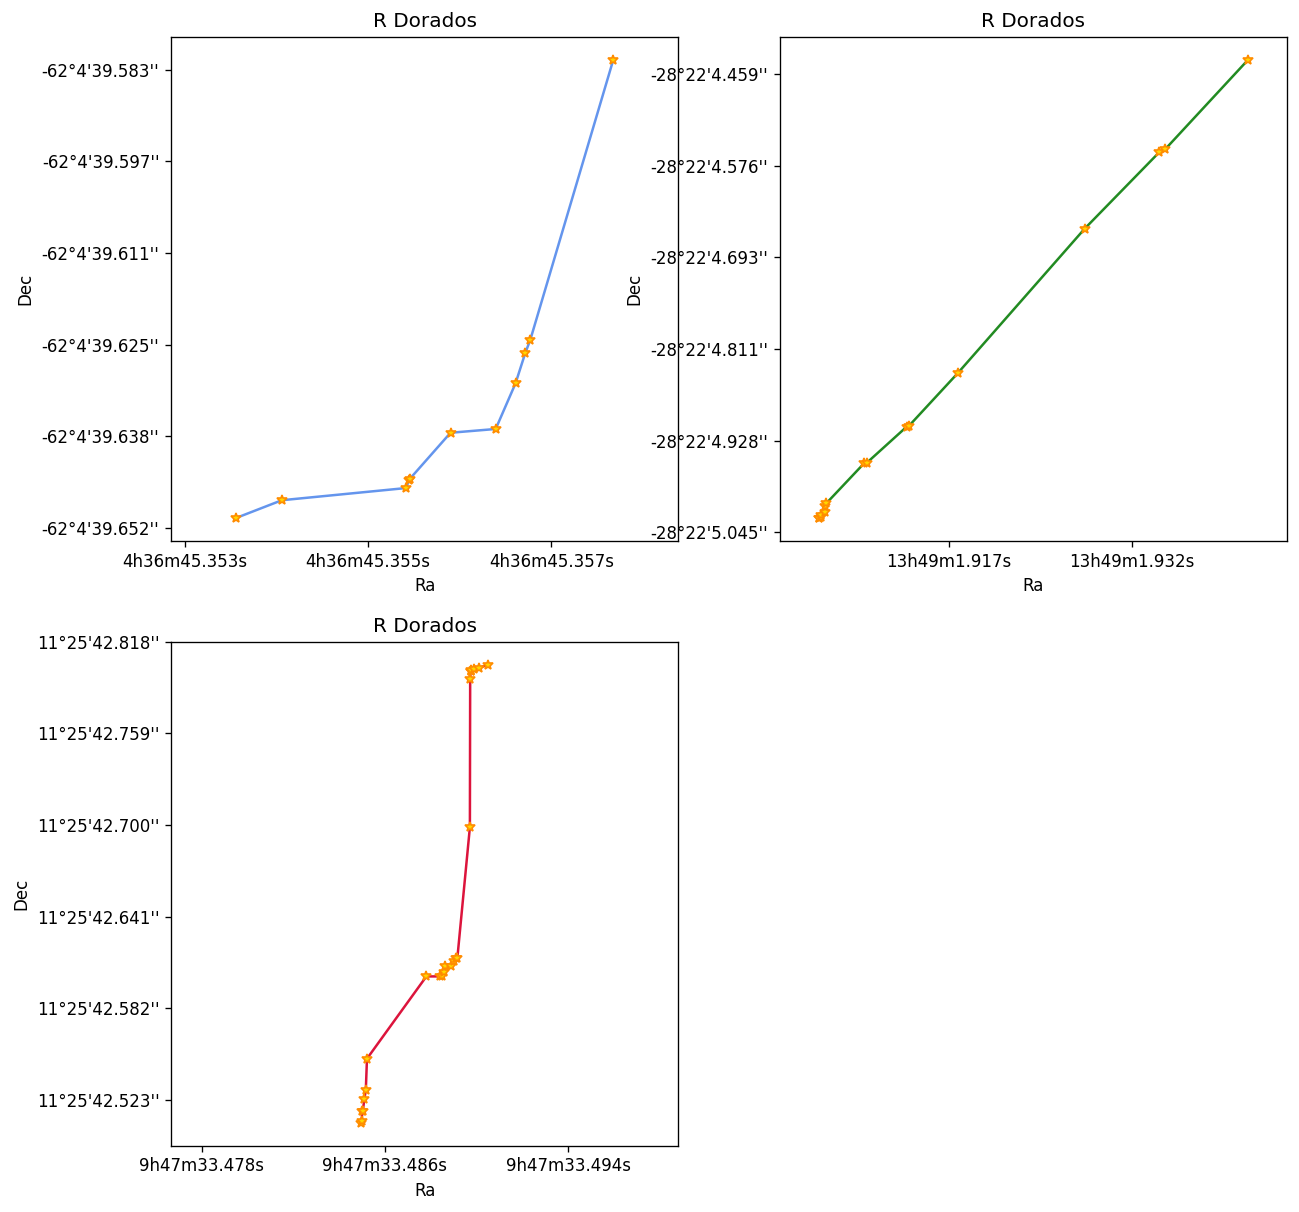

In [ ]:
# Centrum metoder

import matplotlib.ticker as tick

# Hitta centrum med ljusaste punkt:
def maxIntensitet(ras, decs, intensities):
    # Hämta index för ljusaste intensitet
    i, j = np.unravel_index(np.argmax(intensities, axis=None), intensities.shape)

    return ras[i], decs[j], intensities[i, j]

# Få centerpunkter med metod och observationer
# Ger tillbaka tidpunkter, ra:s och dec:s
def getCenters(method, observations):
    ts = []
    ras = []
    decs = []

    # Gå igenom varje observaton
    for observation in observations:
        ts.append(observation[1])
        ra, dec, intensitet = method(observation[2], observation[3], observation[4])

        ras.append(ra)
        decs.append(dec)

    # Sortera datan enligt observationstid
    data = np.array([ts, ras, decs])
    data = np.sort(data)

    return data


# Formatterar deklinationen till string format
def decFormatter(dec, pos): 
    dec_deg = int(dec)
    dec_arcmin = int(60 * (dec - dec_deg))
    dec_arcsec = 60 * (60 * (dec - dec_deg) - dec_arcmin)

    return f"{dec_deg}°{abs(dec_arcmin)}'{abs(dec_arcsec):.3f}''"

# Formatterar rektascension till string format
def raFormatter(ra, pos): 
    ra /= 15
    ra_hour = int(ra)
    ra_min = int(60 * (ra - ra_hour))
    ra_sec = 60 * (60 * (ra - ra_hour) - ra_min)

    return f"{ra_hour}h{abs(ra_min)}m{abs(ra_sec):.3f}s"

# Hämta centrum för stjärnor med max intensitets metod
R_Dor_MaxInt = getCenters(maxIntensitet, R_Dor)
R_Leo_MaxInt = getCenters(maxIntensitet, R_Leo)
W_Hya_MaxInt = getCenters(maxIntensitet, W_Hya)


# Skapa figur för att plotta de olika fallen
fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=120)

# Plottar varje graf från centrum och formatterar axlar
def plotter(ax, centers, color, title):
    ax.plot(centers[1], centers[2], marker='*', color=color, markerfacecolor="gold", markeredgecolor="darkorange")
    ax.axis('equal') # 1 grad RA = 1 grad dec
    ax.set_title(title)
    ax.set_xlabel("Ra")
    ax.set_ylabel("Dec")

    # Formattera ticks så att de har rimligt avstånd (för den långa texten) och rätt dec/ra format
    max_scale = max(np.max(centers[1]) - np.min(centers[1]), np.max(centers[2]) - np.min(centers[2]))
    ax.xaxis.set_major_locator(tick.MultipleLocator(base=0.4*max_scale))
    ax.yaxis.set_major_locator(tick.MultipleLocator(base=0.2*max_scale))
    ax.xaxis.set_major_formatter(tick.FuncFormatter(raFormatter))
    ax.yaxis.set_major_formatter(tick.FuncFormatter(decFormatter))

# Plotta alla centrum
plotter(axs[0,0], R_Dor_MaxInt, "cornflowerblue", "R Dorados")
plotter(axs[1,0], R_Leo_MaxInt, "crimson", "R Leonis")
plotter(axs[0,1], W_Hya_MaxInt, "forestgreen", "R Hydrae")

axs[1,1].set_axis_off()


### Parallax (+Bootstrap)

In [28]:
# Bootstrap

# Parallax

### Analys

In [29]:
# Analys